# Notebook 05: **preguntas y respuestas, resumen automático y traducción**

**Curso:** Procesamiento de Lenguaje Natural — Especialización en Inteligencia Artificial, Universidad de Cundinamarca
**Docente:** Paul Alexander Díaz Montaña
**Autor:** Yohan Nicolás Gómez Castañeda

---

## Objetivo

Construir de cero tres sistemas clásicos —un buscador de respuestas extractivo, un resumidor por
selección de oraciones y un traductor por diccionario y reglas—, **medirlos con las métricas
estándar de cada tarea** (coincidencia exacta y F1 de SQuAD, ROUGE, BLEU y chrF) y determinar
dónde está exactamente el límite de un enfoque sin aprendizaje profundo. El entorno de trabajo no
dispone de modelos preentrenados descargables, de modo que la comparación con un Transformer se
plantea de forma razonada y con el código de referencia listo para ejecutar en Colab.

| Sección | Tema | Pregunta que responde |
|---|---|---|
| 1 | Datos | ¿Qué noticias, preguntas y oraciones se usan en cada tarea? |
| 2 | **Question Answering** | ¿Cuánto se puede responder con recuperación de oraciones más reglas de extracción? ¿Cuándo conviene abstenerse? |
| 3 | **Summarization** | ¿Le gana algún método de grafos a la línea base Lead-3 en prensa de agencia? ¿Cómo se evalúa sin resúmenes humanos? |
| 4 | **Translation** | ¿Qué parte de la traducción resuelve un diccionario bilingüe y qué parte exige modelar el contexto? |
| 5 | Hallazgos | — |

Los tres sistemas comparten las decisiones de preprocesamiento del notebook 01: se conservan las
tildes, se elimina la cabecera de agencia y se usa la lista de stopwords de NLTK sin negaciones.

## 0. Configuración del entorno

In [1]:
# Funciona igual en Google Colab y en local. En Colab clona el repositorio para disponer del paquete `pln_lab`
# y descarga el modelo de spaCy si hace falta.
import importlib.util, os, subprocess, sys
from pathlib import Path

# NLTK debe autorizar el uso del proxy ANTES de cualquier descarga (inocuo en Colab).
os.environ.setdefault("NLTK_ALLOW_PROXIED_URLOPEN", "1")

REPO = "https://github.com/Nicolas2322/lab-procesamiento-texto.git"
EN_COLAB = "google.colab" in sys.modules

def raiz_del_repositorio() -> Path:
    for candidata in [Path.cwd(), *Path.cwd().parents]:
        if (candidata / "src" / "pln_lab").exists():
            return candidata
    if EN_COLAB:
        destino = Path("/content/lab-procesamiento-texto")
        if not destino.exists():
            subprocess.run(["git", "clone", "-q", REPO, str(destino)], check=True)
        return destino
    raise FileNotFoundError("Ejecute el notebook desde la carpeta del repositorio.")

RAIZ = raiz_del_repositorio()
sys.path.insert(0, str(RAIZ / "src"))

if importlib.util.find_spec("es_core_news_md") is None:
    subprocess.run([sys.executable, "-m", "spacy", "download", "es_core_news_md", "-q"], check=True)
if importlib.util.find_spec("sacrebleu") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "sacrebleu"], check=True)

print("Raíz del repositorio:", RAIZ, "| Colab:", EN_COLAB)

Raíz del repositorio: /home/claude/lab-procesamiento-texto | Colab: False


In [2]:
import json, random, re, time
from collections import Counter, defaultdict

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sacrebleu, spacy

from pln_lab.corpus import cargar_documentos_efe, destokenizar
from pln_lab.preprocesamiento import NEGACIONES, quitar_cabecera_agencia, stopwords_nltk
from pln_lab.qa import (
    RecuperadorOraciones, SistemaQA, clasificar_pregunta, coincidencia_exacta, evaluar_qa,
    f1_solapamiento, mejor_puntaje, normalizar_respuesta, separar_alias,
)
from pln_lab.resumen import (
    SELECTORES, cobertura_entidades, cobertura_terminos, matriz_tfidf, redundancia, resumir,
    rouge_completo, similitud_coseno, tasa_compresion, terminos_clave,
)
from pln_lab.traduccion import DICCIONARIO, LOCUCIONES, TraductorReglas, evaluar_traduccion

SEED = 42
random.seed(SEED); np.random.seed(SEED)

DIR_FIG = RAIZ / "notebooks" / "figuras"; DIR_RES = RAIZ / "notebooks" / "resultados"
for d in (DIR_FIG, DIR_RES):
    d.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 4.5), "figure.dpi": 110, "savefig.dpi": 150,
    "savefig.bbox": "tight", "font.size": 10, "axes.grid": True,
    "grid.alpha": 0.25, "axes.spines.top": False, "axes.spines.right": False,
})
AZUL, ROJO, VERDE, GRIS, NARANJA, MORADO = "#2563eb", "#dc2626", "#16a34a", "#6b7280", "#d97706", "#7c3aed"
pd.set_option("display.max_colwidth", 80)

METRICAS = {}

def guardar_figura(nombre):
    plt.savefig(DIR_FIG / f"{nombre}.png"); plt.show()

def pct(x, d=1):
    return f"{100 * x:.{d}f} %"

nlp = spacy.load("es_core_news_md")   # con etiquetador, analizador sintáctico y NER
STOPWORDS = stopwords_nltk() - NEGACIONES
print("spaCy", spacy.__version__, "| sacrebleu", sacrebleu.__version__,
      "| componentes:", nlp.pipe_names)

spaCy 3.8.16 | sacrebleu 2.6.0 | componentes: ['tok2vec', 'morphologizer', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## 1. Datos de las tres tareas

Las tres tareas parten del mismo corpus de noticias de la agencia EFE (CoNLL-2002) usado en los
notebooks anteriores. Cada noticia se reconstruye como lista de oraciones, se le quita la cabecera
de agencia (*«Madrid, 25 may (EFE). -»*) y se descartan los fragmentos de menos de cuatro palabras,
que en este corpus son restos de firmas y códigos de redacción (*«EFE. CSA/SC/fjn/JF.»*).

| Tarea | Conjunto | Contenido |
|---|---|---|
| Question Answering | `datos/qa_efe.csv` | 37 preguntas sobre 8 noticias, con respuestas anotadas a mano y alias separados por `\|`; 4 preguntas no tienen respuesta en el texto |
| Summarization | 12 noticias del corpus | las 12 primeras noticias con 8 a 20 oraciones útiles, descartando las agendas de redacción y los duplicados (mediana de 10 oraciones) |
| Translation | `datos/traduccion_es_en.csv` | 16 oraciones español–inglés: 7 de noticias, 5 con entidades y cifras, 4 modismos |

In [3]:
documentos = cargar_documentos_efe()

def oraciones_de(documento) -> list[str]:
    # Oraciones legibles de una noticia, sin cabecera de agencia ni restos de firma.
    oraciones = [destokenizar([palabra for palabra, _, _ in o]) for o in documento.oraciones]
    oraciones[0] = quitar_cabecera_agencia(oraciones[0])
    return [o for o in oraciones if len(o.split()) > 3]

qa = pd.read_csv(RAIZ / "datos" / "qa_efe.csv").fillna({"respuestas": ""})
traduccion = pd.read_csv(RAIZ / "datos" / "traduccion_es_en.csv")

# El corpus incluye avisos de agenda de la propia redacción ("La Delegación de EFE transmitirá
# hoy las siguientes informaciones: 10:00 h. - Mérida…"), que son listas sin estructura de
# noticia y desvirtuarían cualquier medida de resumen. Se descartan, junto con los documentos
# duplicados (una misma nota reaparece con distinta partición) y los muy cortos o muy largos.
PATRON_AGENDA = re.compile(r"\d{1,2}[:.]\d{2}\s*h\.|siguientes informaciones|transmitirá hoy|- h\. -")

def es_noticia(documento) -> bool:
    oraciones = oraciones_de(documento)
    if not 8 <= len(oraciones) <= 20:
        return False
    if PATRON_AGENDA.search(" ".join(oraciones)):
        return False
    # Una proporción alta de oraciones muy cortas delata una lista, no una crónica.
    return sum(1 for o in oraciones if len(o.split()) < 10) / len(oraciones) < 0.2

noticias_resumen, entradillas_vistas = [], set()
for documento in documentos:
    if not es_noticia(documento):
        continue
    entradilla = oraciones_de(documento)[0][:60]
    if entradilla in entradillas_vistas:
        continue
    entradillas_vistas.add(entradilla)
    noticias_resumen.append(documento)
    if len(noticias_resumen) == 12:
        break

resumen_datos = pd.Series({
    "Noticias del corpus": len(documentos),
    "Preguntas de QA": len(qa),
    "Preguntas sin respuesta": int((qa.tipo == "sin respuesta").sum()),
    "Noticias con preguntas": qa.id_doc.nunique(),
    "Noticias para resumen": len(noticias_resumen),
    "Oraciones útiles por noticia (mediana)": int(np.median([len(oraciones_de(d)) for d in noticias_resumen])),
    "Oraciones para traducir": len(traduccion),
}, name="valor")
METRICAS["datos"] = {k: int(v) for k, v in resumen_datos.items()}
display(resumen_datos.to_frame())
display(qa.tipo.value_counts().rename("preguntas").to_frame().T)

,valor
Noticias del corpus,998
Preguntas de QA,37
Preguntas sin respuesta,4
Noticias con preguntas,8
Noticias para resumen,12
Oraciones útiles por noticia (mediana),10
Oraciones para traducir,16


tipo,cantidad,fecha,otro,lugar,persona,sin respuesta,causa
preguntas,13,5,5,5,4,4,1


## 2. Question Answering extractivo

La tarea es la de SQuAD (Rajpurkar et al., 2016): dada una pregunta y un texto, devolver el
**tramo literal** del texto que la responde, o abstenerse si el texto no la contiene
(SQuAD 2.0; Rajpurkar et al., 2018). El sistema de `pln_lab.qa` la resuelve en tres etapas
separadas para poder atribuir cada error a una de ellas:

1. **Recuperación**: se puntúan todas las oraciones de la noticia frente a la pregunta con TF-IDF
   y coseno, o con BM25, y se conservan las tres mejores.
2. **Extracción**: sobre cada oración candidata se aplica la regla correspondiente al tipo de
   pregunta. Las reglas se apoyan en el reconocedor de entidades y en el etiquetador gramatical de
   spaCy, no en palabras clave:

   | Interrogativo | Tipo | Regla de extracción |
   |---|---|---|
   | *quién* | `persona` | entidades con etiqueta `PER` |
   | *dónde*, *en qué país/ciudad/aeropuerto* | `lugar` | entidades `LOC`; si no hay, `ORG`/`MISC` |
   | *cuánto*, *cuántos* | `cantidad` | tramo que arranca en un numeral (`NUM` o numeral escrito) y se extiende sobre la unidad de medida |
   | *cuándo*, *en qué año* | `fecha` | expresiones temporales localizadas con patrones sobre los nombres de mes y los años |
   | *por qué* | `causa` | tramo que sigue a un nexo causal, o sujeto de un verbo causativo (*obligó*, *provocó*) |
   | *qué*, *cuál*, *cómo* | `otro` | sintagma nominal (`noun_chunks` de spaCy) |

3. **Abstención**: la confianza combina el puntaje de recuperación, la densidad de palabras de la
   pregunta alrededor del tramo y la **cobertura léxica** de la pregunta en la oración. Si no llega
   al umbral, el sistema devuelve la cadena vacía.

Entre varios candidatos del tipo correcto se elige el que tiene más palabras de la pregunta cerca,
ponderadas por el inverso de la distancia, y se descartan los que solo repiten palabras de la
pregunta (un candidato que ya está en la pregunta no puede ser la respuesta).

### 2.1 La etapa de recuperación: ¿está la respuesta en la oración elegida?

In [4]:
ORACIONES_QA = {i: oraciones_de(documentos[i]) for i in qa.id_doc.unique()}
RECUPERADORES = {i: RecuperadorOraciones(ORACIONES_QA[i], STOPWORDS) for i in ORACIONES_QA}
respondibles = qa[qa.tipo != "sin respuesta"]

def acierto_en_k(fila, metodo, k):
    # ¿Aparece alguno de los alias de la respuesta en las k oraciones mejor puntuadas?
    puntajes = RECUPERADORES[fila.id_doc].puntuar(fila.pregunta, metodo)
    mejores = sorted(range(len(puntajes)), key=puntajes.__getitem__, reverse=True)[:k]
    alias = [normalizar_respuesta(a) for a in separar_alias(fila.respuestas)]
    return any(any(a and a in normalizar_respuesta(ORACIONES_QA[fila.id_doc][i]) for a in alias)
               for i in mejores)

KS = [1, 2, 3, 5]
recuperacion = pd.DataFrame(
    {metodo: [np.mean([acierto_en_k(f, metodo, k) for _, f in respondibles.iterrows()]) for k in KS]
     for metodo in ("tfidf", "bm25")}, index=[f"acierto@{k}" for k in KS])
METRICAS["qa_recuperacion"] = {c: {f"@{k}": round(v, 4) for k, v in zip(KS, recuperacion[c])}
                               for c in recuperacion}
display(recuperacion.map(lambda v: f"{v:.1%}"))

,tfidf,bm25
acierto@1,81.8%,84.8%
acierto@2,93.9%,93.9%
acierto@3,97.0%,97.0%
acierto@5,100.0%,100.0%


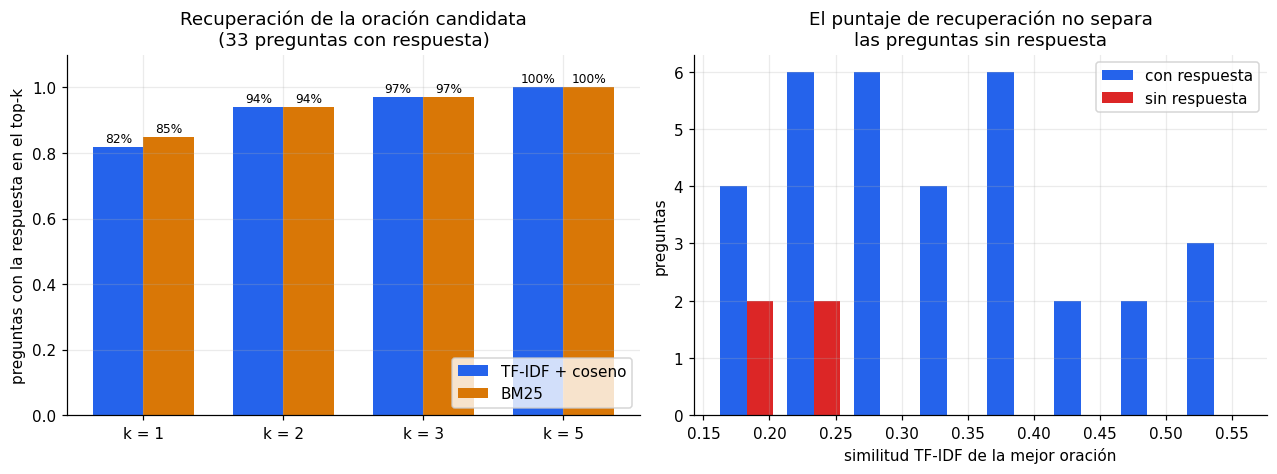

Similitud media — con respuesta: 0.328 | sin respuesta: 0.212


In [5]:
fig, ejes = plt.subplots(1, 2, figsize=(11.5, 4.2), layout="constrained")
ancho = 0.36
for j, (metodo, color, etiqueta) in enumerate([("tfidf", AZUL, "TF-IDF + coseno"), ("bm25", NARANJA, "BM25")]):
    ejes[0].bar(np.arange(len(KS)) + (j - 0.5) * ancho, recuperacion[metodo], ancho,
                color=color, label=etiqueta)
    for x, v in zip(np.arange(len(KS)) + (j - 0.5) * ancho, recuperacion[metodo]):
        ejes[0].text(x, v + 0.015, f"{v:.0%}", ha="center", fontsize=8)
ejes[0].set(xticks=range(len(KS)), xticklabels=[f"k = {k}" for k in KS], ylim=(0, 1.1),
            ylabel="preguntas con la respuesta en el top-k",
            title="Recuperación de la oración candidata\n(33 preguntas con respuesta)")
ejes[0].legend(loc="lower right")

# Distribución del puntaje de la mejor oración: preguntas con y sin respuesta.
mejores_con = [RECUPERADORES[f.id_doc].mejor(f.pregunta)[1] for _, f in respondibles.iterrows()]
mejores_sin = [RECUPERADORES[f.id_doc].mejor(f.pregunta)[1]
               for _, f in qa[qa.tipo == "sin respuesta"].iterrows()]
ejes[1].hist([mejores_con, mejores_sin], bins=8, color=[AZUL, ROJO],
             label=["con respuesta", "sin respuesta"])
ejes[1].set(xlabel="similitud TF-IDF de la mejor oración", ylabel="preguntas",
            title="El puntaje de recuperación no separa\nlas preguntas sin respuesta")
ejes[1].legend()
guardar_figura("fig05_01_qa_recuperacion")
print("Similitud media — con respuesta:", round(float(np.mean(mejores_con)), 3),
      "| sin respuesta:", round(float(np.mean(mejores_sin)), 3))

**Análisis.** La recuperación no es el cuello de botella. Con TF-IDF, la oración que contiene la
respuesta es la primera en el 81,8 % de las 33 preguntas respondibles, está entre las tres primeras
en el 97,0 % y entre las cinco primeras en el 100 %. BM25 mejora ligeramente el acierto@1
(84,8 %) porque su saturación de la frecuencia de término penaliza las oraciones largas que
repiten una palabra de la pregunta, pero a partir de k = 2 ambos métodos coinciden: en documentos
de 6 a 13 oraciones la señal léxica basta. Por eso el sistema extrae sobre las **tres** mejores
oraciones y las reordena según la extracción: recuperar tres en lugar de una sube el techo del
81,8 % al 97,0 % a cambio de triplicar el trabajo de extracción, que es barato.

El histograma de la derecha muestra el problema de fondo de la abstención. La similitud media de la
mejor oración es 0,328 para las preguntas con respuesta y 0,212 para las que no la tienen, pero la
media engaña: los cuatro valores de las preguntas sin respuesta caen entre 0,171 y 0,246, y **7 de
las 33 preguntas respondibles tienen una similitud igual o menor**. Un umbral sobre la similitud
sola que descartara las cuatro sin respuesta se llevaría por delante esas siete. La razón es que una
pregunta sin respuesta (*«¿Cuánto cuesta la entrada a la exposición?»*) comparte con la noticia todo
su vocabulario temático y solo le falta el dato, mientras que una pregunta respondible formulada con
otras palabras que el texto puntúa bajo. **El puntaje de recuperación por sí solo no sirve como
criterio de abstención**: hace falta la señal de que no existe un candidato del tipo pedido, que es
lo que aporta la etapa de extracción.

### 2.2 Las 37 predicciones frente a la referencia

In [6]:
def ejecutar_qa(umbral=0.40, metodo="tfidf", k=3):
    sistema = SistemaQA(nlp=nlp, stopwords=STOPWORDS, metodo_recuperacion=metodo,
                        umbral=umbral, k_oraciones=k)
    return [sistema.responder(ORACIONES_QA[f.id_doc], f.pregunta, RECUPERADORES[f.id_doc])
            for _, f in qa.iterrows()]

t0 = time.time()
respuestas = ejecutar_qa()
segundos = time.time() - t0

tabla_qa = pd.DataFrame({
    "id": qa.id_doc, "tipo": qa.tipo, "pregunta": qa.pregunta,
    "predicción": [r.texto for r in respuestas],
    "referencia": qa.respuestas,
    "EM": [mejor_puntaje(r.texto, ref, coincidencia_exacta) for r, ref in zip(respuestas, qa.respuestas)],
    "F1": [mejor_puntaje(r.texto, ref, f1_solapamiento) for r, ref in zip(respuestas, qa.respuestas)],
    "conf.": [round(r.confianza, 3) for r in respuestas],
    "or.": [r.indice_oracion for r in respuestas],
})
global_qa = evaluar_qa(tabla_qa["predicción"].tolist(), qa.respuestas.tolist())
METRICAS["qa_global"] = {k: round(v, 2) for k, v in global_qa.items()}
print(f"37 preguntas en {segundos:.1f} s — coincidencia exacta {global_qa['em']:.1f} | F1 {global_qa['f1']:.1f}")
vista = tabla_qa.assign(EM=tabla_qa.EM.map("{:.0f}".format), F1=tabla_qa.F1.map("{:.2f}".format))
with pd.option_context("display.max_rows", 40, "display.max_colwidth", 46):
    display(vista)

37 preguntas en 0.4 s — coincidencia exacta 59.5 | F1 65.0


,id,tipo,pregunta,predicción,referencia,EM,F1,conf.,or.
0,5,fecha,¿Hasta cuándo estará abierta la exposición...,el próximo 28 de junio,28 de junio|el próximo 28 de junio,1,1.00,0.422,0
1,5,otro,¿De qué nacionalidad es el artista que exp...,artista rumano,rumano,0,0.67,0.429,0
2,5,cantidad,¿Cuántas piezas componen la exposición?,35 piezas,35|35 piezas,1,1.00,0.585,0
3,5,lugar,¿En qué país reside actualmente Edward Lei...,Bélgica,Bélgica,1,1.00,0.428,2
4,5,persona,¿Quién es el concejal de Cultura?,Francisco Torres,Francisco Torres,1,1.00,0.435,4
5,5,sin respuesta,¿Cuánto cuesta la entrada a la exposición?,,,1,1.00,0.297,0
6,13,cantidad,¿A cuánto ascendían las reservas de oro y ...,600 millones de dólares,18.300 millones de dólares,0,0.67,0.505,0
7,13,cantidad,¿Cuánto subieron las reservas de oro y div...,600 millones de dólares,600 millones de dólares,1,1.00,0.528,0
8,13,cantidad,¿En qué precio por onza se basa la valorac...,300 dólares estadounidenses,300 dólares estadounidenses por cada onza ...,1,1.00,0.442,3
9,20,otro,¿Qué arma llevaba el secuestrador?,,una granada|una granada de mano|granada|gr...,0,0.00,0.335,1


### 2.3 El umbral de abstención

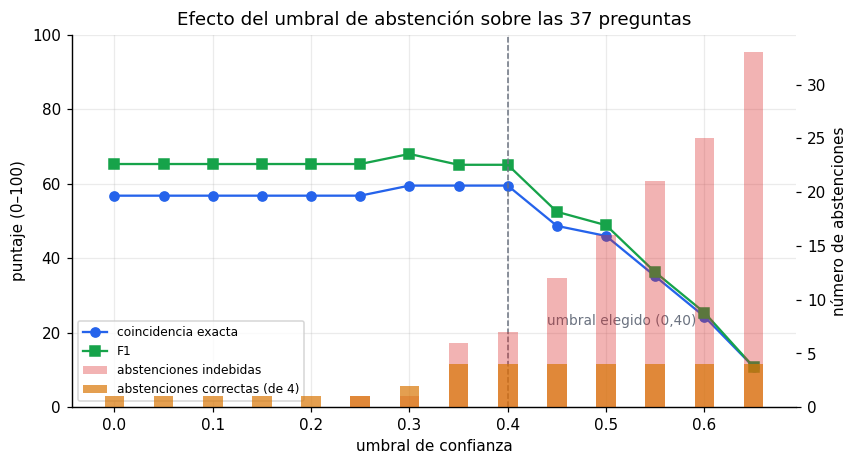

,umbral,EM,F1,abstenciones correctas,abstenciones indebidas
0,0.00,56.756757,65.249795,1,0
1,0.05,56.756757,65.249795,1,0
2,0.10,56.756757,65.249795,1,0
3,0.15,56.756757,65.249795,1,0
4,0.20,56.756757,65.249795,1,0
5,0.25,56.756757,65.249795,1,1
6,0.30,59.459459,67.952498,2,1
7,0.35,59.459459,65.045045,4,6
8,0.40,59.459459,65.045045,4,7
9,0.45,48.648649,52.432432,4,12


In [7]:
filas = []
for umbral in np.round(np.arange(0.0, 0.66, 0.05), 2):
    lote = ejecutar_qa(umbral=umbral)
    predicciones = [r.texto for r in lote]
    m = evaluar_qa(predicciones, qa.respuestas.tolist())
    sin_respuesta = (qa.tipo == "sin respuesta").values
    abstenido = np.array([r.abstenido for r in lote])
    filas.append({"umbral": umbral, "EM": m["em"], "F1": m["f1"],
                  "abstenciones correctas": int((abstenido & sin_respuesta).sum()),
                  "abstenciones indebidas": int((abstenido & ~sin_respuesta).sum())})
barrido = pd.DataFrame(filas)
METRICAS["qa_umbral"] = barrido.round(2).to_dict("records")

fig, eje = plt.subplots(figsize=(8.5, 4.4))
eje.plot(barrido.umbral, barrido.EM, "o-", color=AZUL, label="coincidencia exacta")
eje.plot(barrido.umbral, barrido.F1, "s-", color=VERDE, label="F1")
eje.axvline(0.40, color=GRIS, ls="--", lw=1)
eje.annotate("umbral elegido (0,40)", (0.40, 20), xytext=(0.44, 22), fontsize=9, color=GRIS)
eje.set(xlabel="umbral de confianza", ylabel="puntaje (0–100)", ylim=(0, 100),
        title="Efecto del umbral de abstención sobre las 37 preguntas")
eje2 = eje.twinx(); eje2.grid(False)
eje2.bar(barrido.umbral, barrido["abstenciones indebidas"], width=0.02, color=ROJO, alpha=0.35,
         label="abstenciones indebidas")
eje2.bar(barrido.umbral, barrido["abstenciones correctas"], width=0.02, color=NARANJA, alpha=0.7,
         label="abstenciones correctas (de 4)")
eje2.set_ylabel("número de abstenciones")
lineas = eje.get_legend_handles_labels()[0] + eje2.get_legend_handles_labels()[0]
etiquetas = eje.get_legend_handles_labels()[1] + eje2.get_legend_handles_labels()[1]
eje.legend(lineas, etiquetas, loc="lower left", fontsize=8)
guardar_figura("fig05_02_qa_umbral")
display(barrido)

**Análisis.** El umbral gobierna el compromiso entre responder y callar. Sin abstención (umbral 0)
el sistema alcanza 56,8 de coincidencia exacta y 65,2 de F1, y solo acierta 1 de las 4 preguntas sin
respuesta: en las otras tres entrega un tramo del tipo correcto tomado de una oración que no
responde (*«¿Cuánto cuesta la entrada a la exposición?»* → *«28»*, tomado de la fecha de cierre de la
exposición). Subir el umbral hace ganar dos veces, porque en SQuAD 2.0 abstenerse en una pregunta
sin respuesta puntúa exactamente igual que acertar el tramo: con 0,30 el sistema llega a su mejor F1
(59,5 / **68,0**) con 2 de 4 abstenciones correctas y solo 1 indebida, y con 0,40 consigue las
**4 de 4** a costa de 7 abstenciones indebidas (59,5 / 65,0). Se adopta 0,40 porque el objetivo de
la tarea incluye detectar lo que no se puede responder, y porque la coincidencia exacta —la métrica
más estricta— es idéntica en los dos puntos. Por encima de 0,45 el sistema empieza a callar en
preguntas que sí sabía responder y el puntaje se hunde: 35,1 de coincidencia exacta con umbral 0,55.

Que la curva tenga un máximo plano entre 0,30 y 0,40 y caiga en vertical después indica que la
confianza está **mal calibrada**: es un número construido sumando tres señales heterogéneas con
pesos elegidos a mano (0,35 / 0,35 / 0,30), no una probabilidad. Un modelo entrenado sobre
SQuAD 2.0 aprende a producir, para cada intervalo posible, una puntuación comparable con la del
tramo nulo, y por eso puede fijar el umbral con un criterio estadístico en vez de por barrido.

### 2.4 Resultados por tipo de pregunta y taxonomía de errores

In [8]:
tabla_qa["EM"] = tabla_qa["EM"].astype(float)
por_tipo = (tabla_qa.groupby("tipo")[["EM", "F1"]].mean() * 100).round(1)
por_tipo["preguntas"] = tabla_qa.groupby("tipo").size()
METRICAS["qa_por_tipo"] = por_tipo.to_dict("index")

# Comparación de las dos funciones de recuperación con el resto de la tubería fija.
comparacion_metodos = {}
for metodo in ("tfidf", "bm25"):
    lote = ejecutar_qa(metodo=metodo)
    comparacion_metodos[metodo] = evaluar_qa([r.texto for r in lote], qa.respuestas.tolist())
METRICAS["qa_metodos"] = {k: {kk: round(vv, 2) for kk, vv in v.items()}
                          for k, v in comparacion_metodos.items()}
display(por_tipo)
print("Tubería completa según la función de recuperación:",
      {k: f"EM {v['em']:.1f} / F1 {v['f1']:.1f}" for k, v in comparacion_metodos.items()})

,EM,F1,preguntas
tipo,,,
cantidad,69.2,77.4,13
causa,0.0,0.0,1
fecha,60.0,60.0,5
lugar,40.0,46.7,5
otro,20.0,33.3,5
persona,75.0,75.0,4
sin respuesta,100.0,100.0,4


Tubería completa según la función de recuperación: {'tfidf': 'EM 59.5 / F1 65.0', 'bm25': 'EM 56.8 / F1 65.2'}


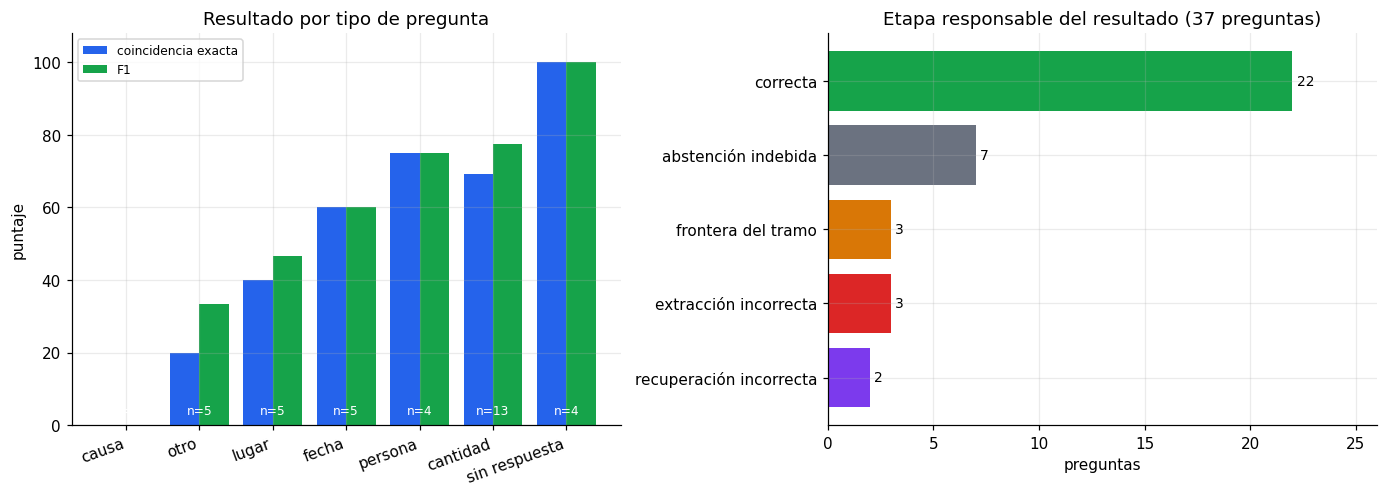

,tipo,pregunta,predicción,referencia,diagnóstico
0,otro,¿De qué nacionalidad es el artista que expone en Alcorcón?,artista rumano,rumano,frontera del tramo
1,cantidad,¿A cuánto ascendían las reservas de oro y divisas de Rusia el 19 de mayo?,600 millones de dólares,18.300 millones de dólares,frontera del tramo
2,otro,¿Qué arma llevaba el secuestrador?,,una granada|una granada de mano|granada|granada de mano,abstención indebida
3,causa,¿Por qué el avión no pudo regresar a Davao?,,la falta de combustible|falta de combustible,abstención indebida
4,cantidad,¿Cuánto dinero le robaron a la víctima?,,1.500 pesetas,abstención indebida
5,persona,¿Quién dirige la orquesta en el concierto de Sabadell?,,Máximo Zumalave,abstención indebida
6,lugar,¿Dónde se celebrará el concierto?,Sabadell,el teatro municipal La Farándula de Sabadell|teatro municipal La Farándula|L...,frontera del tramo
7,fecha,¿Cuándo se constituyó públicamente la orquesta?,,en el mes de febrero de 1996|febrero de 1996,abstención indebida
8,fecha,¿En qué año fueron Arias y Chávez compañeros de cuartelazo?,,1992,abstención indebida
9,otro,¿Qué diario publica la entrevista con Arias?,el diario madrileño,El Pais,extracción incorrecta


In [9]:
def clasificar_error(respuesta, fila):
    # Atribuye cada pregunta a la etapa responsable del resultado.
    em = mejor_puntaje(respuesta.texto, fila.respuestas, coincidencia_exacta)
    f1 = mejor_puntaje(respuesta.texto, fila.respuestas, f1_solapamiento)
    alias = [normalizar_respuesta(a) for a in separar_alias(fila.respuestas)]
    respuesta_en_oracion = any(a and a in normalizar_respuesta(respuesta.oracion) for a in alias)
    if em == 1:
        return "correcta"
    if fila.tipo == "sin respuesta":
        return "falso positivo (debía abstenerse)"
    if respuesta.abstenido:
        return "abstención indebida"
    if not respuesta_en_oracion:
        return "recuperación incorrecta"
    return "frontera del tramo" if f1 > 0 else "extracción incorrecta"

tabla_qa["diagnóstico"] = [clasificar_error(r, f) for r, (_, f) in zip(respuestas, qa.iterrows())]
conteo_errores = tabla_qa["diagnóstico"].value_counts()
METRICAS["qa_errores"] = conteo_errores.to_dict()

fig, ejes = plt.subplots(1, 2, figsize=(12.5, 4.4), layout="constrained")
orden = por_tipo.sort_values("F1").index
x = np.arange(len(orden))
ejes[0].bar(x - 0.2, por_tipo.loc[orden, "EM"], 0.4, color=AZUL, label="coincidencia exacta")
ejes[0].bar(x + 0.2, por_tipo.loc[orden, "F1"], 0.4, color=VERDE, label="F1")
for xi, t in zip(x, orden):
    ejes[0].text(xi, 3, f"n={por_tipo.loc[t, 'preguntas']}", ha="center", fontsize=8, color="white")
ejes[0].set(xticks=x, ylim=(0, 108), ylabel="puntaje", title="Resultado por tipo de pregunta")
ejes[0].set_xticklabels(orden, rotation=20, ha="right")
ejes[0].legend(fontsize=8)

colores = {"correcta": VERDE, "frontera del tramo": NARANJA, "extracción incorrecta": ROJO,
           "recuperación incorrecta": MORADO, "abstención indebida": GRIS,
           "falso positivo (debía abstenerse)": "#111827"}
etiquetas = conteo_errores.index[::-1]
ejes[1].barh(range(len(etiquetas)), conteo_errores[etiquetas],
             color=[colores.get(e, GRIS) for e in etiquetas])
for i, v in enumerate(conteo_errores[etiquetas]):
    ejes[1].text(v + 0.2, i, str(v), va="center", fontsize=9)
ejes[1].set(yticks=range(len(etiquetas)), yticklabels=etiquetas, xlim=(0, 26),
            xlabel="preguntas", title="Etapa responsable del resultado (37 preguntas)")
guardar_figura("fig05_03_qa_por_tipo")
display(tabla_qa[tabla_qa["diagnóstico"] != "correcta"]
        [["tipo", "pregunta", "predicción", "referencia", "diagnóstico"]]
        .reset_index(drop=True))

**Análisis.** El resultado global es 59,5 de coincidencia exacta y 65,0 de F1 con TF-IDF
(56,8 / 65,2 con BM25: el acierto@1 algo mejor de BM25 no se traslada al resultado final porque la
reordenación con la extracción ya recupera la oración correcta de todos modos). La diferencia por tipo de pregunta
es enorme y **sigue exactamente la especificidad de la regla**:

- **`persona` (75,0) y `cantidad` (69,2 de coincidencia exacta y 77,4 de F1)** son los tipos donde la regla acierta.
  Una pregunta por *quién* se resuelve con las entidades `PER` de la oración, y una por *cuánto*
  con el numeral más la unidad. En ambos casos el tipo de respuesta es una categoría que el modelo
  de spaCy ya marca, y el único problema que queda es elegir entre dos candidatos del mismo tipo.
- **`fecha` (60,0)** no falla por localizar la fecha sino por la frontera del tramo y por el umbral:
  la referencia dice *«en el mes de febrero de 1996»*, el sistema encuentra *«el mes de febrero de
  1996»* —una preposición de diferencia— y la confianza se queda justo por debajo de 0,40, de modo
  que el sistema se calla una respuesta que tenía.
- **`lugar` (40,0)** y **`otro` (20,0)** son los tipos débiles. En *lugar* el problema es que la
  pregunta pide un tipo de lugar específico (*«¿A qué hospital…?»*, *«¿Qué ciudad…?»*) y la etiqueta
  `LOC` no distingue hospital de ciudad ni ciudad de departamento: ante *«es Pasto, la capital del
  departamento de Nariño, la ciudad que presenta la situación más crítica»* el sistema elige
  *Nariño* porque está más cerca de las palabras de la pregunta. En *otro* la regla es la más vaga
  de todas —cualquier sintagma nominal— y devuelve el sintagma equivocado: *«El ciclista italiano»*
  en lugar de *«una fractura del fémur derecho»*.
- **`causa` (0,0)** falla en la única pregunta de su clase: el sistema se abstiene. Merece un
  párrafo propio.
- **`sin respuesta` (100,0)**: las cuatro abstenciones son correctas.

La taxonomía de la derecha reparte las 37 preguntas: **22 correctas**, **7 abstenciones indebidas**,
**3 errores de frontera** del tramo, **3 de extracción** (la oración correcta, el candidato
equivocado) y **2 de recuperación** (la oración elegida no contiene la respuesta). Los tres grupos
de error son de naturaleza distinta:

1. **Recuperación correcta, extracción incorrecta.** *«¿A cuánto ascendían las reservas de oro y
   divisas de Rusia el 19 de mayo?»* recupera la oración correcta, que contiene dos cantidades
   —*«subieron 600 millones de dólares»* y *«equivalían a 18.300 millones de dólares»*— y elige la
   primera, porque *reservas*, *oro*, *divisas* y *Rusia* están más cerca de ella. La regla de
   proximidad léxica no puede saber que el verbo *ascender* se corresponde con *equivaler* y no con
   *subir*: eso exige similitud semántica entre la pregunta y el contexto del candidato, no
   coincidencia de palabras.
2. **Fronteras del tramo.** *«rumano»* frente a *«artista rumano»* (F1 = 0,67), *«el teatro municipal
   La Farándula de Sabadell»* frente a *«Sabadell»* (F1 = 0,33), *«en el mes de febrero de 1996»*
   frente a *«el mes de febrero de 1996»*. La coincidencia exacta castiga una palabra de más o de
   menos con un cero; el F1 de solapamiento refleja mucho mejor lo que el sistema encontró, y la
   distancia entre las dos métricas —59,5 frente a 65,0— es casi toda de este tipo. En un sistema de
   reglas la frontera se fija con una heurística de extensión escrita a mano; un modelo entrenado
   predice **dos distribuciones**, una para el token inicial y otra para el final, y aprende de miles
   de ejemplos dónde cortan los anotadores.
3. **Preguntas de causa.** *«¿Por qué el avión no pudo regresar a Davao?»* tiene como respuesta
   *«la falta de combustible»*, que aparece como sujeto de *obligó* dentro de una oración
   subordinada: *«el secuestrador pidió al piloto que volviera a Davao … pero la falta de
   combustible obligó a seguir ruta a Manila»*. La respuesta no comparte **ninguna** palabra con la
   pregunta: *regresar* no es *volver*, y *no pudo* no es *obligó a seguir ruta*. La recuperación
   léxica prefiere las oraciones que repiten *avión* y *Davao* y no explican nada, así que ninguna
   de las tres candidatas contiene un nexo causal utilizable y el sistema acaba absteniéndose. Que
   se abstenga en lugar de inventar es el comportamiento preferible, pero el resultado es 0 en el
   único tipo de pregunta que exige inferencia: es el caso que ningún sistema de superficie puede
   resolver.

### 2.5 Qué haría un modelo tipo BERT-SQuAD

Un modelo extractivo entrenado sobre SQuAD (Devlin et al., 2019; Rajpurkar et al., 2018) sustituye
las tres etapas por una sola: codifica la concatenación *[CLS] pregunta [SEP] contexto [SEP]* con
atención bidireccional y predice, para cada token del contexto, la probabilidad de ser el inicio y
el final de la respuesta. Eso cambia los tres errores anteriores:

- **No necesita clasificar la pregunta.** El tipo de respuesta esperado queda implícito en la
  representación de la pregunta; no hay una tabla de interrogativos que se quede corta ante
  *«¿A qué hospital…?»*.
- **Compara significado, no palabras.** *ascendían* y *equivalían*, o *no pudo regresar* y *obligó a
  seguir ruta*, quedan cerca en el espacio de representaciones contextuales, de modo que la pregunta
  de causa deja de ser un caso imposible. En el conjunto de desarrollo de SQuAD 2.0 los modelos de
  esta familia superan 80 de F1, frente al 65,0 de este sistema.
- **La frontera es aprendida.** Las dos distribuciones de inicio y fin están entrenadas con las
  convenciones de los anotadores, lo que elimina la mayoría de los errores de preposición inicial.
- **La abstención está calibrada.** El tramo nulo (posición `[CLS]`) compite con los demás tramos
  con la misma puntuación, así que el umbral se ajusta sobre una escala comparable.

El código de referencia para ejecutarlo en Colab —donde sí hay acceso a los modelos preentrenados—
queda a continuación **sin ejecutar**, porque este entorno no puede descargarlos.

In [10]:
# CÓDIGO DE REFERENCIA — no se ejecuta aquí (sin acceso a los modelos preentrenados).
# En Colab: !pip install -q transformers torch
#
# from transformers import pipeline
#
# # Modelo extractivo multilingüe afinado en SQuAD; para español también sirve
# # "mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es" (BETO afinado en SQuAD 2.0),
# # que admite respuesta vacía y por tanto la abstención.
# qa_transformer = pipeline(
#     "question-answering",
#     model="mrm8488/bert-base-spanish-wwm-cased-finetuned-spa-squad2-es",
#     handle_impossible_answer=True,   # habilita el tramo nulo de SQuAD 2.0
# )
#
# predicciones_bert = []
# for _, fila in qa.iterrows():
#     contexto = " ".join(ORACIONES_QA[fila.id_doc])      # la noticia completa, sin trocear
#     salida = qa_transformer(question=fila.pregunta, context=contexto, top_k=1)
#     # salida["score"] es comparable entre preguntas: el umbral se calibra sobre él.
#     predicciones_bert.append("" if salida["score"] < 0.30 else salida["answer"])
#
# # Se evalúa con las MISMAS funciones de este notebook, para que la comparación sea válida.
# print(evaluar_qa(predicciones_bert, qa.respuestas.tolist()))
#
# # Comparación por tipo de pregunta:
# # comparativa = qa.assign(
# #     em_reglas=[mejor_puntaje(r.texto, ref, coincidencia_exacta) for r, ref in zip(respuestas, qa.respuestas)],
# #     em_bert=[mejor_puntaje(p, ref, coincidencia_exacta) for p, ref in zip(predicciones_bert, qa.respuestas)],
# # ).groupby("tipo")[["em_reglas", "em_bert"]].mean()
print("Celda de referencia para Colab: no se ejecuta en este entorno.")

Celda de referencia para Colab: no se ejecuta en este entorno.


## 3. Summarization extractiva

Resumir de forma **extractiva** es seleccionar un subconjunto de oraciones del documento. Se
comparan seis selectores implementados en `pln_lab.resumen`, todos con la misma interfaz:

| Método | Criterio |
|---|---|
| **Lead-1**, **Lead-3** | las 1 o 3 primeras oraciones (pirámide invertida) |
| **TextRank** | PageRank sobre el grafo de oraciones con similitud del coseno TF-IDF (Mihalcea y Tarau, 2004) |
| **LexRank** | PageRank sobre el grafo binarizado por umbral, con coseno modificado por IDF (Erkan y Radev, 2004) |
| **SumBasic** | selección voraz por probabilidad media de palabra, con penalización de lo ya cubierto (Nenkova y Vanderwende, 2005) |
| **Posición+longitud** | heurística de dominio: posición relativa y longitud cercana a la mediana |

TextRank y LexRank están implementados aquí —matriz de similitud, matriz de transición e
iteración de potencias— sin librerías de grafos, para que se vea que la diferencia entre ambos no
está en el algoritmo de ranking sino en **cómo se construye el grafo**: TextRank conserva todas las
aristas con su peso, LexRank descarta las que no superan un umbral.

**El problema de la evaluación.** El corpus de EFE no trae resúmenes escritos por humanos, así que
no hay referencia contra la que calcular ROUGE en su uso habitual. Se usan dos estrategias
complementarias: métricas **sin referencia**, que miden propiedades del resumen respecto del
documento, y un ROUGE contra **Lead-3 como pseudo-referencia**, que mide parecido con la línea base,
no calidad.

In [11]:
def analizar_noticia(documento):
    # Calcula todas las métricas de todos los métodos para una noticia.
    oraciones = oraciones_de(documento)
    texto = " ".join(oraciones)
    entidades = {e.text for e in nlp(texto).ents}
    claves = terminos_clave(texto, oraciones, STOPWORDS, k=10)
    similitud = similitud_coseno(matriz_tfidf(oraciones, STOPWORDS)[0])
    pseudo_referencia, _ = resumir(oraciones, SELECTORES["Lead-3"], 3, STOPWORDS)
    filas = []
    for nombre, selector in SELECTORES.items():
        n = 1 if nombre == "Lead-1" else 3
        resumen, indices = resumir(oraciones, selector, n, STOPWORDS)
        filas.append({
            "doc": documento.id, "método": nombre, "oraciones": len(oraciones),
            "compresión": tasa_compresion(resumen, texto),
            "cobertura entidades": cobertura_entidades(resumen, entidades),
            "cobertura términos": cobertura_terminos(resumen, claves),
            "redundancia": redundancia(indices, similitud),
            **rouge_completo(resumen, pseudo_referencia),
            "índices": tuple(indices), "resumen": resumen,
        })
    return filas

t0 = time.time()
detalle_resumen = pd.DataFrame([f for d in noticias_resumen for f in analizar_noticia(d)])
print(f"12 noticias × 6 métodos en {time.time() - t0:.1f} s")

COLUMNAS = ["compresión", "cobertura entidades", "cobertura términos", "redundancia",
            "ROUGE-1", "ROUGE-2", "ROUGE-L"]
ORDEN = ["Lead-1", "Lead-3", "TextRank", "LexRank", "SumBasic", "Posición+longitud"]
promedios = detalle_resumen.groupby("método")[COLUMNAS].mean().loc[ORDEN]
METRICAS["resumen"] = promedios.round(4).to_dict("index")
display(promedios.round(3))

12 noticias × 6 métodos en 1.1 s


,compresión,cobertura entidades,cobertura términos,redundancia,ROUGE-1,ROUGE-2,ROUGE-L
método,,,,,,,
Lead-1,0.098,0.212,0.575,0.000,0.507,0.501,0.507
Lead-3,0.291,0.509,0.825,0.069,1.000,1.000,1.000
TextRank,0.288,0.408,0.850,0.137,0.661,0.537,0.595
LexRank,0.304,0.464,0.800,0.116,0.611,0.444,0.499
SumBasic,0.270,0.427,0.950,0.039,0.647,0.509,0.511
Posición+longitud,0.305,0.532,0.825,0.078,0.951,0.943,0.948


### 3.1 Métricas sin referencia humana

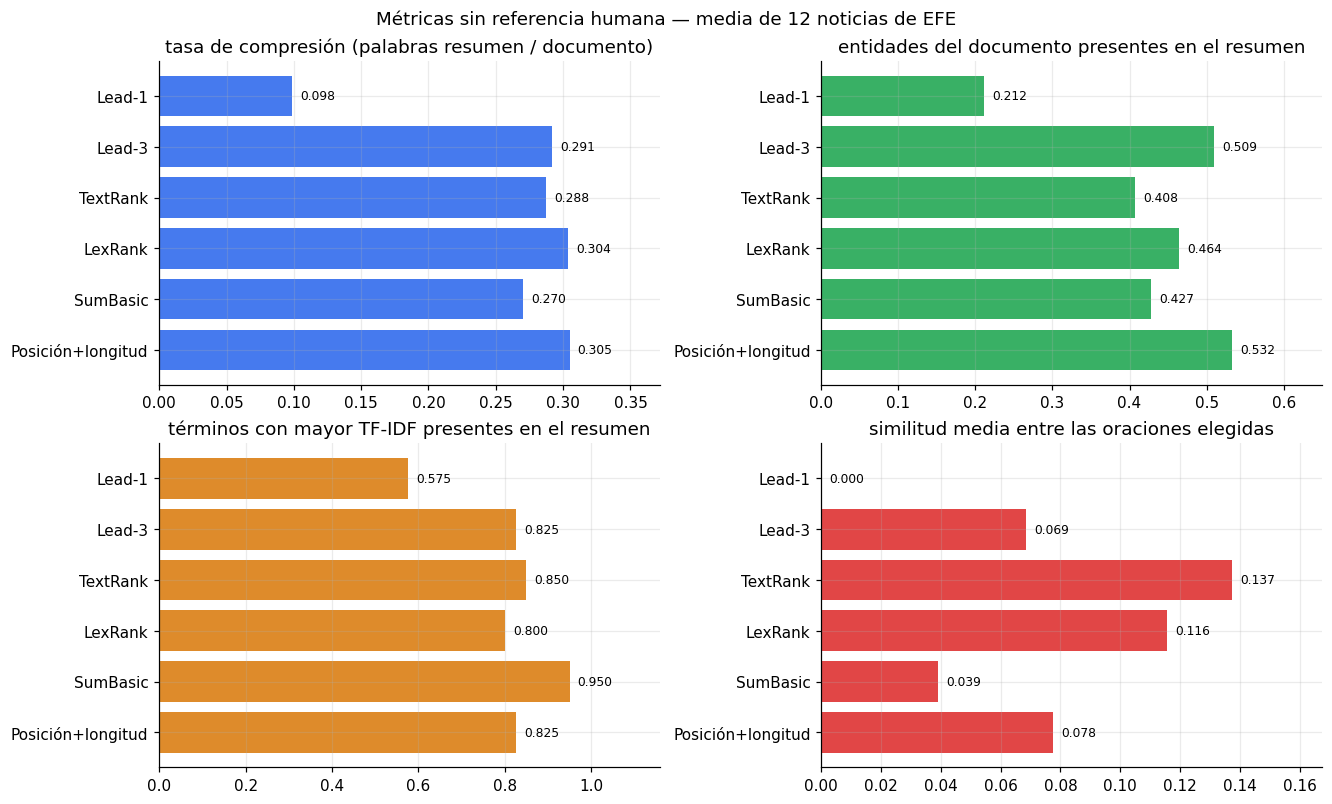

In [12]:
paneles = [("compresión", "tasa de compresión (palabras resumen / documento)", AZUL),
           ("cobertura entidades", "entidades del documento presentes en el resumen", VERDE),
           ("cobertura términos", "términos con mayor TF-IDF presentes en el resumen", NARANJA),
           ("redundancia", "similitud media entre las oraciones elegidas", ROJO)]
fig, ejes = plt.subplots(2, 2, figsize=(12, 7.2), layout="constrained")
for eje, (columna, titulo, color) in zip(ejes.ravel(), paneles):
    valores = promedios[columna]
    barras = eje.barh(range(len(valores)), valores, color=color, alpha=0.85)
    for i, v in enumerate(valores):
        eje.text(v + valores.max() * 0.02, i, f"{v:.3f}", va="center", fontsize=8)
    eje.set(yticks=range(len(valores)), yticklabels=valores.index,
            xlim=(0, valores.max() * 1.22), title=titulo)
    eje.invert_yaxis()
fig.suptitle("Métricas sin referencia humana — media de 12 noticias de EFE", fontsize=12)
guardar_figura("fig05_04_resumen_metricas")

**Análisis.** Las cuatro métricas describen compromisos distintos y **ningún método gana en todas**.

La **compresión** separa Lead-1 (0,098: un resumen de una oración deja fuera el 90 % de las
palabras) de los métodos de tres oraciones, que se agrupan entre 0,270 (SumBasic) y 0,305
(Posición+longitud). Que SumBasic comprima más con el mismo número de oraciones significa que elige
oraciones más cortas, y es consecuencia directa de su criterio: la probabilidad **media** de palabra
premia las oraciones breves hechas de palabras frecuentes.

La **cobertura de entidades** es la métrica donde Lead gana con claridad: Posición+longitud recupera
el 53,2 % de las entidades nombradas del documento y Lead-3 el 50,9 %, frente al 46,4 % de LexRank,
el 42,7 % de SumBasic y el 40,8 % de TextRank. La explicación es la estructura de la noticia de
agencia: la entradilla nombra a los protagonistas —quién, dónde, cuándo— y el cuerpo los sustituye
por pronombres y referencias anafóricas (*«el funcionario agregó»*, *«dicha ciudad»*, *«la otra
víctima»*). Un método que elige oraciones del cuerpo por su centralidad léxica recoge esas menciones
vacías de entidad.

La **cobertura de términos TF-IDF** invierte el orden: SumBasic 95,0 %, TextRank 85,0 %,
Lead-3 y Posición+longitud 82,5 %, LexRank 80,0 %. Es coherente, porque los dos criterios son casi
el mismo: SumBasic maximiza explícitamente la frecuencia de las palabras del documento y TextRank
premia las oraciones que comparten vocabulario con muchas otras, es decir, las que contienen el
vocabulario central. La contradicción con la métrica anterior es el hallazgo: **los métodos de
grafos y de frecuencia cubren mejor el vocabulario temático y peor las entidades**, porque las
entidades son términos de IDF alta que aparecen en pocas oraciones y por eso no hacen central a
ninguna.

La **redundancia** mide lo que cada método no controla. TextRank es el peor (0,137, el doble que
Lead-3 con 0,069) y por una razón estructural: si dos oraciones dicen casi lo mismo, se refuerzan
mutuamente en el grafo y las dos suben en el ranking. Es el defecto conocido del método —se ve en
el primer ejemplo de la sección 3.3, donde TextRank elige dos oraciones que repiten la misma cifra
de ampliación de capital—, y es lo que LexRank mitiga a medias (0,116) al binarizar el grafo y
SumBasic resuelve de raíz (0,039) al elevar al cuadrado la probabilidad de las palabras ya usadas.
Es también el argumento para las variantes con penalización explícita de la similitud, como MMR
(*maximal marginal relevance*).

### 3.2 ROUGE contra Lead-3 como pseudo-referencia

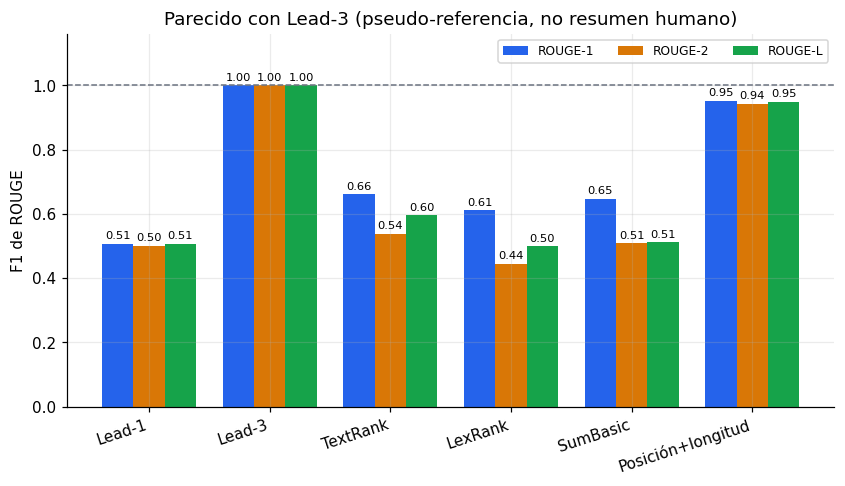

Fracción media de oraciones compartidas con Lead-3: {'Lead-1': '0.33', 'Lead-3': '1.00', 'TextRank': '0.47', 'LexRank': '0.36', 'SumBasic': '0.47', 'Posición+longitud': '0.92'}


In [13]:
fig, eje = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(ORDEN)); ancho = 0.26
for j, (metrica, color) in enumerate([("ROUGE-1", AZUL), ("ROUGE-2", NARANJA), ("ROUGE-L", VERDE)]):
    eje.bar(x + (j - 1) * ancho, promedios[metrica], ancho, color=color, label=metrica)
    for xi, v in zip(x + (j - 1) * ancho, promedios[metrica]):
        eje.text(xi, v + 0.015, f"{v:.2f}", ha="center", fontsize=7.5)
eje.axhline(1.0, color=GRIS, ls="--", lw=1)
eje.set(xticks=x, ylim=(0, 1.16), ylabel="F1 de ROUGE",
        title="Parecido con Lead-3 (pseudo-referencia, no resumen humano)")
eje.set_xticklabels(ORDEN, rotation=18, ha="right")
eje.legend(fontsize=8, ncol=3)
guardar_figura("fig05_05_resumen_rouge")

solapamiento = {m: float(np.mean([len(set(i) & {0, 1, 2}) / 3
                                  for i in detalle_resumen[detalle_resumen["método"] == m]["índices"]]))
                for m in ORDEN}
METRICAS["resumen_solape_lead3"] = {k: round(v, 3) for k, v in solapamiento.items()}
print("Fracción media de oraciones compartidas con Lead-3:",
      {k: f"{v:.2f}" for k, v in solapamiento.items()})

**Análisis.** Antes de leer las cifras hay que decir qué miden y qué no. **Lead-3 no es un resumen
de referencia**: es la línea base más simple posible, escrita por nadie. Un ROUGE alto contra ella
significa «este método se parece a tomar el principio del texto», no «este método resume bien». La
interpretación correcta de la figura es como **medida de divergencia respecto de la línea base**, y
en ese sentido informa mucho:

- **Posición+longitud obtiene 0,951 de ROUGE-1** y comparte de media 0,92 de sus oraciones con
  Lead-3. Era previsible: su puntaje está dominado por el término de posición, así que es Lead-3 con
  un ajuste de longitud. Sirve como control de que la métrica funciona.
- **TextRank (0,661 de ROUGE-1; 0,537 de ROUGE-2) y LexRank (0,611 / 0,444)** seleccionan
  contenido parcialmente distinto: comparten con Lead-3 el 47 % y el 36 % de sus oraciones
  respectivamente. La caída de ROUGE-1 a ROUGE-2 —de 0,661 a 0,537 en TextRank— confirma que no se
  trata de oraciones parecidas sino de oraciones diferentes que reutilizan el vocabulario de la
  noticia.
- **Lead-1 obtiene 0,507**, exactamente lo que cabe esperar de un resumen que es un subconjunto
  propio de la referencia: precisión perfecta, recuperación de un tercio.

**Por qué Lead es una línea base durísima en prensa de agencia.** La noticia de agencia se escribe
en pirámide invertida: la entradilla contesta las seis preguntas canónicas (*qué, quién, cuándo,
dónde, cómo, por qué*) y cada párrafo siguiente añade detalle decreciente, de modo que el texto se
pueda cortar por abajo en cualquier punto para ajustarlo al hueco de la página. Es decir, **el
redactor ya escribió un resumen extractivo y lo puso al principio**. Un método que reordena
oraciones por centralidad léxica compite contra una selección hecha por un profesional con
conocimiento del tema. En los resultados de DUC y en la literatura de resumen esto es un hecho
conocido: en noticias, Lead-3 es difícil de superar y durante años fue el punto de referencia que
había que batir, mientras que en dominios sin esa convención —artículos científicos, transcripciones
de reuniones, hilos de correo— la posición deja de ser informativa y los métodos de grafos ganan
con holgura. Las métricas de esta sección lo confirman: Lead-3 gana en cobertura de entidades y en
redundancia, y pierde en cobertura de vocabulario temático.

### 3.3 Tres resúmenes concretos

In [14]:
for documento in noticias_resumen[:3]:
    oraciones = oraciones_de(documento)
    print("=" * 110)
    print(f"NOTICIA {documento.id} — {len(oraciones)} oraciones, {len(' '.join(oraciones).split())} palabras")
    print(f"Entradilla: {oraciones[0][:300]}")
    print("-" * 110)
    for nombre in ["Lead-3", "TextRank", "LexRank", "SumBasic"]:
        resumen, indices = resumir(oraciones, SELECTORES[nombre], 3, STOPWORDS)
        print(f"· {nombre:18s} oraciones {list(indices)} — {len(resumen.split())} palabras")
        print(f"  {resumen[:420]}{'…' if len(resumen) > 420 else ''}")
    print()

NOTICIA 6 — 10 oraciones, 436 palabras
Entradilla: La ampliación de capital máxima de Terra para el canje de acciones con Lycos, incluidas las opciones sobre acciones de los trabajadores de la empresa estadounidense, no excederá de 340.922.712 acciones que, al precio del cierre de ayer en bolsa (50,9 pesetas por acción), sería de 2,887 billones de p
--------------------------------------------------------------------------------------------------------------
· Lead-3             oraciones [0, 1, 2] — 126 palabras
  La ampliación de capital máxima de Terra para el canje de acciones con Lycos, incluidas las opciones sobre acciones de los trabajadores de la empresa estadounidense, no excederá de 340.922.712 acciones que, al precio del cierre de ayer en bolsa (50,9 pesetas por acción), sería de 2,887 billones de pesetas. Así consta en una nota aclaratoria del grupo Telefónica a la Comisión Nacional del Mercado de Valores sobre las …
· TextRank           oraciones [0, 3, 6] — 145 palabras
 

**Análisis.** Los tres ejemplos muestran cuándo TextRank gana a Lead y cuándo no.

**Cuándo no gana: la redundancia.** En la noticia sobre la ampliación de capital de Terra, TextRank
elige las oraciones 0, 3 y 6, y la oración 3 repite la misma cifra de la 0 (*«La ampliación de
340.922.712 acciones…»*). Es el defecto del grafo en estado puro: las dos oraciones son casi
idénticas, se refuerzan mutuamente y las dos ascienden. Lead-3 no puede caer en eso porque no
puntúa nada. Es también la razón de que TextRank tenga la peor redundancia media (0,137) de los seis
métodos.

**Cuándo no gana: las anáforas.** En la noticia sobre Sierra Leona, SumBasic prescinde de la
entradilla y selecciona las oraciones 11, 13 y 15, que empiezan por *«Kurt Shork, la otra
víctima…»* y *«Los periodistas fueron asaltados…»*: el lector no sabe quién es la primera víctima ni
qué periodistas. Cubre bien el léxico (95,0 % de los términos TF-IDF) y no cuenta el hecho. Es el
patrón general de los métodos que ignoran la posición.

**Cuándo sí gana.** En la crónica sobre la prensa italiana y la final de la Liga de Campeones,
Lead-3 gasta sus tres oraciones en el titular y en un comentario sobre la maquetación de los diarios
deportivos, mientras que TextRank conserva la entradilla y cambia la segunda y la tercera por los
titulares concretos de *La Gazzetta dello Sport* y de *Corriere dello Sport*, que es la información
que la noticia va acumulando a lo largo del texto. LexRank llega a descartar la entradilla y
seleccionar las oraciones 1, 3 y 10. Ese es el régimen favorable: **cuando la información relevante
está repartida por el cuerpo en lugar de concentrada en la entradilla**, la centralidad léxica la
localiza y la posición no. En los 12 documentos TextRank conserva la primera oración en 11 casos y
solo cambia la segunda y la tercera, de modo que en la práctica funciona como un refinamiento de
Lead, no como una alternativa.

## 4. Translation español→inglés

`datos/traduccion_es_en.csv` contiene 16 oraciones con su traducción de referencia escrita a mano,
en tres categorías pensadas para aislar tres dificultades distintas:

| Categoría | Oraciones | Qué pone a prueba |
|---|---|---|
| `noticia` | 7 | sintaxis y morfología del español periodístico |
| `entidad_cifra` | 5 | nombres propios, exónimos y cantidades |
| `modismo` | 4 | expresiones no composicionales (*tomar el pelo*, *quedar en agua de borrajas*, *lavarse las manos*, *poner el grito en el cielo*) |

El traductor de `pln_lab.traduccion` es de la primera generación de la traducción automática:
diccionario bilingüe más reglas de transferencia. El diccionario se construyó con el vocabulario de
las 16 oraciones más las palabras más frecuentes del corpus EFE, de modo que **la cobertura léxica
no sea el factor limitante**: si el sistema falla no será por palabras que no conoce. Las reglas
son cuatro: contracciones (*del* → *of the*), reordenamiento sustantivo–adjetivo, supresión del
pronombre reflexivo, y generación de la morfología inglesa (plural nominal, tercera persona,
pasado, participio, gerundio, futuro con *will*) a partir de los rasgos que anota spaCy.

In [15]:
traductor = TraductorReglas(nlp=nlp)
traduccion["hipótesis"] = [traductor(o) for o in traduccion.es]
cobertura = 1 - len(traductor.faltantes) / sum(len(nlp(o)) for o in traduccion.es)
METRICAS["traduccion_diccionario"] = {
    "entradas": len(DICCIONARIO), "locuciones": len(LOCUCIONES),
    "palabras_fuera_del_diccionario": sorted(traductor.faltantes),
    "cobertura_lexica": round(cobertura, 4),
}
print(f"Diccionario: {len(DICCIONARIO)} entradas + {len(LOCUCIONES)} locuciones "
      f"| palabras sin entrada: {sorted(traductor.faltantes) or 'ninguna'}")
with pd.option_context("display.max_colwidth", 78):
    display(traduccion[["categoria", "es", "hipótesis", "en"]])

Diccionario: 330 entradas + 15 locuciones | palabras sin entrada: ninguna


,categoria,es,hipótesis,en
0,noticia,El museo acoge una exposición de esculturas en vidrio.,The museum hosts an exhibition of sculptures in glass.,The museum is hosting an exhibition of glass sculptures.
1,noticia,La defensa ha solicitado la absolución de los dos jóvenes.,The defense has requested the acquittal of the two young men.,The defense has requested the acquittal of the two young men.
2,noticia,El avión tomó tierra sin problemas en el aeropuerto.,The plane took ground without problems in the airport.,The plane landed without problems at the airport.
3,noticia,Las intensas lluvias castigan al país desde hace seis días.,The heavy rains punish to the country for six days.,The heavy rains have been battering the country for six days.
4,noticia,La orquesta interpretará obras de compositores clásicos.,The orchestra will perform works of classical composers.,The orchestra will perform works by classical composers.
5,noticia,El ciclista italiano sufre una fractura del fémur derecho.,The Italian cyclist suffers a fracture of the right femur.,The Italian cyclist has a fracture of the right femur.
6,noticia,El candidato presidencial promete revisar la Constitución.,The presidential candidate promises to review the constitution.,The presidential candidate promises to review the Constitution.
7,entidad_cifra,Las reservas de oro y divisas de Rusia subieron 600 millones de dólares.,The reserves of gold and currencies of Russia rose 600 million of dollars.,Russia's gold and foreign currency reserves rose by 600 million dollars.
8,entidad_cifra,El avión llevaba 280 pasajeros y despegó del aeropuerto de Davao.,The plane carried 280 passengers and took off of the airport of Davao.,The plane was carrying 280 passengers and took off from the airport of Davao.
9,entidad_cifra,La exposición está compuesta por 35 piezas de diferentes formatos.,The exhibition is made up by 35 pieces of different formats.,The exhibition is made up of 35 pieces of different formats.


In [16]:
def bleu_chrf(subconjunto):
    return evaluar_traduccion(subconjunto["hipótesis"].tolist(), subconjunto["en"].tolist())

filas = [{"categoría": "todas", "oraciones": len(traduccion), **bleu_chrf(traduccion)}]
for categoria in ["noticia", "entidad_cifra", "modismo"]:
    sub = traduccion[traduccion.categoria == categoria]
    filas.append({"categoría": categoria, "oraciones": len(sub), **bleu_chrf(sub)})
tabla_mt = pd.DataFrame(filas)[["categoría", "oraciones", "bleu", "chrf", "precisiones"]]
METRICAS["traduccion_por_categoria"] = tabla_mt.drop(columns="precisiones").round(2).to_dict("records")
display(tabla_mt.round(2))

# Intervalo de confianza por remuestreo: 16 oraciones son muy pocas para un BLEU estable.
generador = np.random.default_rng(SEED)
muestras = []
for _ in range(1000):
    indices = generador.integers(0, len(traduccion), len(traduccion))
    muestras.append(sacrebleu.corpus_bleu([traduccion["hipótesis"].iloc[i] for i in indices],
                                          [[traduccion["en"].iloc[i] for i in indices]]).score)
ic = np.percentile(muestras, [2.5, 97.5])
METRICAS["traduccion_ic95"] = [round(float(ic[0]), 2), round(float(ic[1]), 2)]
print(f"BLEU global {tabla_mt.bleu[0]:.2f} — intervalo de confianza del 95 % por remuestreo: "
      f"[{ic[0]:.2f}, {ic[1]:.2f}]")

,categoría,oraciones,bleu,chrf,precisiones
0,todas,16,49.78,75.34,"[77.8409090909091, 58.125, 42.361111111111114, 32.03125]"
1,noticia,7,61.37,82.28,"[86.11111111111111, 69.23076923076923, 55.172413793103445, 43.13725490196079]"
2,entidad_cifra,5,55.02,77.07,"[82.08955223880596, 64.51612903225806, 47.36842105263158, 36.53846153846154]"
3,modismo,4,11.59,52.46,"[54.054054054054056, 24.242424242424242, 6.896551724137931, 2.0]"


BLEU global 49.78 — intervalo de confianza del 95 % por remuestreo: [34.98, 62.69]


,bleu,chrf
completo,49.77692,75.34402
sin reordenar sust.+adj.,44.898762,72.723527
sin locuciones,44.265562,73.467326
sin morfología (solo diccionario),23.456807,66.478667


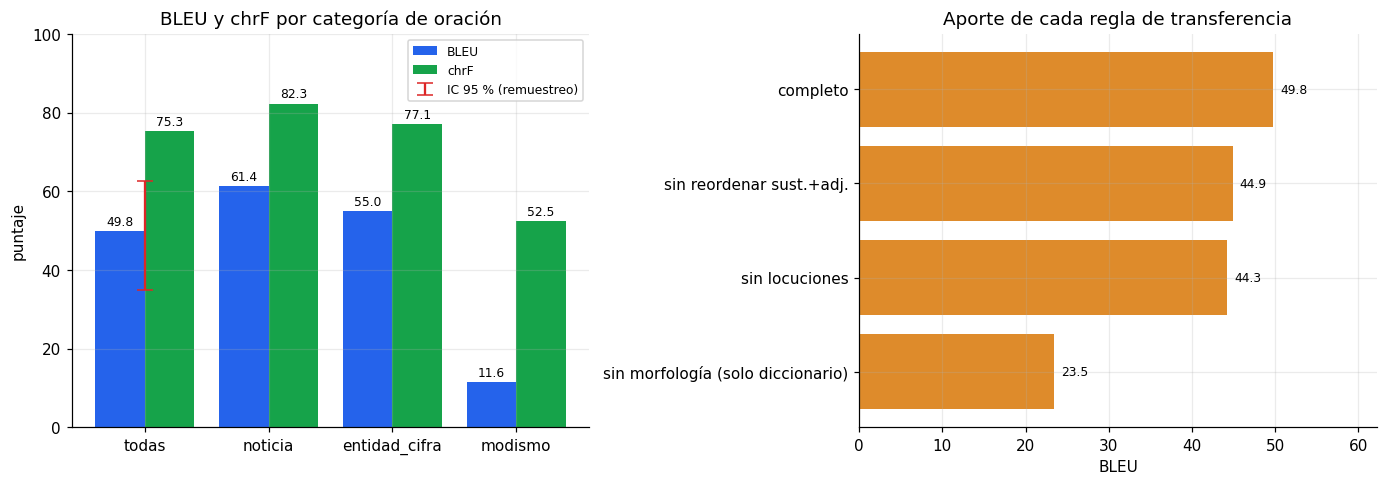

In [17]:
# Ablaciones: cuánto aporta cada regla de transferencia.
ablaciones = {
    "completo": TraductorReglas(nlp=nlp),
    "sin reordenar sust.+adj.": TraductorReglas(nlp=nlp, reordenar_adjetivos=False),
    "sin locuciones": TraductorReglas(nlp=nlp, locuciones={}),
    "sin morfología (solo diccionario)": None,
}
resultados_ablacion = {}
for nombre, modelo in ablaciones.items():
    if modelo is None:      # se anula la generación morfológica: se emite la forma base
        modelo = TraductorReglas(nlp=nlp)
        modelo.generar = lambda token, traduccion, auxiliar=None: traduccion
    hipotesis = [modelo(o) for o in traduccion.es]
    resultados_ablacion[nombre] = evaluar_traduccion(hipotesis, traduccion.en.tolist())
tabla_ablacion = pd.DataFrame(resultados_ablacion).T[["bleu", "chrf"]].round(2)
METRICAS["traduccion_ablaciones"] = tabla_ablacion.to_dict("index")
display(tabla_ablacion)

fig, ejes = plt.subplots(1, 2, figsize=(12.5, 4.3), layout="constrained")
categorias = tabla_mt["categoría"]
x = np.arange(len(categorias))
ejes[0].bar(x - 0.2, tabla_mt.bleu, 0.4, color=AZUL, label="BLEU")
ejes[0].bar(x + 0.2, tabla_mt.chrf, 0.4, color=VERDE, label="chrF")
for xi, v in zip(x - 0.2, tabla_mt.bleu):
    ejes[0].text(xi, v + 1.5, f"{v:.1f}", ha="center", fontsize=8)
for xi, v in zip(x + 0.2, tabla_mt.chrf):
    ejes[0].text(xi, v + 1.5, f"{v:.1f}", ha="center", fontsize=8)
ejes[0].errorbar([0], [tabla_mt.bleu[0]], yerr=[[tabla_mt.bleu[0] - ic[0]], [ic[1] - tabla_mt.bleu[0]]],
                 fmt="none", ecolor=ROJO, capsize=5, lw=1.5, label="IC 95 % (remuestreo)")
ejes[0].set(xticks=x, xticklabels=categorias, ylim=(0, 100), ylabel="puntaje",
            title="BLEU y chrF por categoría de oración")
ejes[0].legend(fontsize=8)

ejes[1].barh(range(len(tabla_ablacion)), tabla_ablacion.bleu, color=NARANJA, alpha=0.85)
for i, v in enumerate(tabla_ablacion.bleu):
    ejes[1].text(v + 0.8, i, f"{v:.1f}", va="center", fontsize=8)
ejes[1].set(yticks=range(len(tabla_ablacion)), yticklabels=tabla_ablacion.index,
            xlim=(0, tabla_ablacion.bleu.max() * 1.25), xlabel="BLEU",
            title="Aporte de cada regla de transferencia")
ejes[1].invert_yaxis()
guardar_figura("fig05_06_traduccion_bleu_chrf")

**Análisis.** El resultado global —BLEU 49,78 y chrF 75,34— es **engañosamente bueno y hay que
leerlo con tres reservas**.

La primera es estadística: con 16 oraciones el intervalo de confianza del 95 % por remuestreo va de
34,98 a 62,69, casi veintiocho puntos. Cualquier comparación entre sistemas con esta cantidad de
datos es indistinguible del ruido. Los conjuntos de prueba de traducción tienen miles de oraciones
por esta razón.

La segunda es de diseño de la referencia. Las referencias las escribió el mismo autor del
diccionario, y en las oraciones de noticia la traducción natural al inglés es casi palabra por
palabra, porque el español periodístico y el inglés periodístico comparten el orden
sujeto–verbo–objeto y la estructura de los sintagmas. Eso favorece al sistema con una sola
referencia: BLEU premia la coincidencia de n-gramas, no la corrección. Un conjunto con varias
referencias por oración, o con oraciones de registro más libre, daría cifras mucho más bajas.

La tercera es la que importa, y se ve en la descomposición por categoría:

| Categoría | BLEU | chrF | Qué revela |
|---|---|---|---|
| `noticia` | 61,37 | 82,28 | el diccionario y las reglas resuelven la oración periodística simple |
| `entidad_cifra` | 55,02 | 77,07 | los nombres propios se copian bien, pero *«las reservas de oro y divisas de Rusia»* sale como *«the reserves of gold and currencies of Russia»* en vez de *«Russia's gold and foreign currency reserves»* |
| `modismo` | **11,59** | 52,46 | el sistema colapsa |

**El desplome en los modismos es el resultado central del experimento**, y es un desplome
cualitativo, no de grado. *«La reforma quedó en agua de borrajas»* se traduce como *«The reform
remained in water of borages»*: cada palabra está bien traducida y la oración no significa nada.
*«Los vecinos pusieron el grito en el cielo»* → *«The neighbours put the shout in the sky»* frente a
*«The neighbours hit the roof»*. *«El alcalde se lavó las manos»* → *«The mayor washed the hands»*,
donde además se pierde el posesivo que el inglés exige (*his hands*). Que chrF se mantenga en 52,46
mientras BLEU cae a 11,59 es informativo: chrF trabaja con n-gramas de **caracteres** y sigue
premiando *the*, *in*, *the* y los sufijos coincidentes; BLEU con n-gramas de palabras detecta que
no hay ni un tetragrama correcto. Cuando las dos métricas divergen así, la traducción es
léxicamente plausible y semánticamente falsa.

Las cuatro causas del fracaso, en orden de gravedad:

1. **No composicionalidad.** El significado de un modismo no es función del significado de sus
   partes, y un traductor palabra a palabra es por construcción composicional. La única salida
   dentro de este paradigma es una tabla de expresiones, que no generaliza: haría falta una entrada
   por modismo, y el español tiene decenas de miles.
2. **Ambigüedad léxica sin contexto.** *por* se traduce como *by*, *for*, *through* o *because of*
   según la construcción; el diccionario tiene que elegir una. En *«está compuesta por 35 piezas»*
   la elección *by* produce *«is made up by»* en lugar de *«of»*. Lo mismo con *quedar*
   (*remain* / *be left* / *end up*) y *sufrir* (*suffer* / *have*). Sin modelo del contexto, cada
   palabra polisémica es una apuesta fija.
3. **Orden de palabras más allá del adjetivo.** La regla de reordenamiento sustantivo–adjetivo
   aporta 4,9 puntos de BLEU (49,78 frente a 44,90 sin ella), y es la única reordenación que el
   sistema sabe hacer. No sabe convertir *«las reservas de Rusia»* en el genitivo sajón
   *«Russia's reserves»*, ni *«el avión llevaba»* en la forma progresiva *«the plane was carrying»*,
   ni mover un complemento. Las locuciones aportan otros 5,5 puntos (44,27 sin ellas), lo que
   confirma que incluso las unidades funcionales pequeñas (*al menos*, *desde hace*) exigen
   tratamiento pluriverbal.
4. **Morfología.** Es la regla que más aporta con diferencia: sin generación morfológica —emitiendo
   la forma base del diccionario— el BLEU cae de 49,78 a **23,46**, menos de la mitad. Traducir sin
   flexión produce *«The museum host a exhibition»* y *«The plane take ground»*. Aun con ella quedan
   errores sistemáticos: los clíticos (*nos está tomando* → *«we is taking»*, con el pronombre átono
   convertido en sujeto), los participios usados como sustantivos (*18.000 damnificados* →
   *«18000 victim»*, sin plural, porque spaCy los etiqueta como adjetivos) y la concordancia
   sujeto–verbo cuando el sujeto no es el token inmediatamente anterior.

### 4.1 Un seq2seq mínimo con Keras: qué pasa con 16 oraciones

In [18]:
# Experimento de control: ¿qué hace una arquitectura neuronal con la cantidad de datos disponible?
# 13 oraciones de entrenamiento, 3 de prueba, modelo diminuto. El objetivo es ver el sobreajuste,
# no obtener una traducción.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"       # silencia los mensajes de arranque de TensorFlow
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
try:
    import tensorflow as tf
    from tensorflow import keras
    tf.random.set_seed(SEED)

    INICIO, FIN = "\t", "\n"
    entradas = [o.lower() for o in traduccion.es]
    salidas = [INICIO + o.lower() + FIN for o in traduccion.en]

    tok_es = keras.preprocessing.text.Tokenizer(filters="", lower=True)
    tok_en = keras.preprocessing.text.Tokenizer(filters="", lower=True)
    tok_es.fit_on_texts(entradas); tok_en.fit_on_texts(salidas)
    V_ES, V_EN = len(tok_es.word_index) + 1, len(tok_en.word_index) + 1
    X = keras.preprocessing.sequence.pad_sequences(tok_es.texts_to_sequences(entradas), padding="post")
    Y = keras.preprocessing.sequence.pad_sequences(tok_en.texts_to_sequences(salidas), padding="post")
    L_ES, L_EN = X.shape[1], Y.shape[1]
    ENTRENAMIENTO, PRUEBA = list(range(13)), [13, 14, 15]

    DIM = 64
    ent_cod = keras.Input(shape=(L_ES,)); ent_dec = keras.Input(shape=(L_EN - 1,))
    emb_cod = keras.layers.Embedding(V_ES, DIM, mask_zero=True)(ent_cod)
    _, h, c = keras.layers.LSTM(DIM, return_state=True)(emb_cod)
    emb_dec = keras.layers.Embedding(V_EN, DIM, mask_zero=True)(ent_dec)
    sal_dec = keras.layers.LSTM(DIM, return_sequences=True)(emb_dec, initial_state=[h, c])
    salida = keras.layers.Dense(V_EN, activation="softmax")(sal_dec)
    modelo = keras.Model([ent_cod, ent_dec], salida)
    modelo.compile(optimizer=keras.optimizers.Adam(5e-3),
                   loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    historia = modelo.fit([X[ENTRENAMIENTO], Y[ENTRENAMIENTO, :-1]], Y[ENTRENAMIENTO, 1:],
                          validation_data=([X[PRUEBA], Y[PRUEBA, :-1]], Y[PRUEBA, 1:]),
                          epochs=300, batch_size=4, verbose=0)

    def traducir_seq2seq(indice):
        # Decodificación voraz reutilizando el modelo completo (el conjunto es diminuto).
        secuencia = np.zeros((1, L_EN - 1), dtype="int32")
        secuencia[0, 0] = tok_en.word_index.get(INICIO.strip() or "\t", 1)
        palabras = []
        for paso in range(L_EN - 2):
            probabilidades = modelo.predict([X[indice:indice + 1], secuencia], verbose=0)[0, paso]
            siguiente = int(np.argmax(probabilidades))
            palabra = tok_en.index_word.get(siguiente, "")
            if not palabra or palabra == FIN.strip():
                break
            palabras.append(palabra)
            secuencia[0, paso + 1] = siguiente
        return " ".join(palabras)

    hip_entrenamiento = [traducir_seq2seq(i) for i in ENTRENAMIENTO]
    hip_prueba = [traducir_seq2seq(i) for i in PRUEBA]
    bleu_entrenamiento = sacrebleu.corpus_bleu(
        hip_entrenamiento, [[traduccion.en.iloc[i] for i in ENTRENAMIENTO]]).score
    bleu_prueba = sacrebleu.corpus_bleu(hip_prueba, [[traduccion.en.iloc[i] for i in PRUEBA]]).score
    reglas_prueba = sacrebleu.corpus_bleu([traduccion["hipótesis"].iloc[i] for i in PRUEBA],
                                          [[traduccion.en.iloc[i] for i in PRUEBA]]).score
    METRICAS["seq2seq"] = {"parametros": int(modelo.count_params()),
                           "bleu_entrenamiento": round(bleu_entrenamiento, 2),
                           "bleu_prueba": round(bleu_prueba, 2),
                           "bleu_prueba_reglas": round(reglas_prueba, 2),
                           "perdida_final": round(float(historia.history["loss"][-1]), 4),
                           "perdida_validacion_final": round(float(historia.history["val_loss"][-1]), 4)}
    print(f"Parámetros: {modelo.count_params():,} | pérdida entrenamiento "
          f"{historia.history['loss'][-1]:.4f} | validación {historia.history['val_loss'][-1]:.4f}")
    print(f"BLEU sobre las 13 de entrenamiento: {bleu_entrenamiento:.2f}")
    print(f"BLEU sobre las 3 de prueba:         {bleu_prueba:.2f}  "
          f"(traductor de reglas en las mismas 3: {reglas_prueba:.2f})")
    for i, h in zip(PRUEBA, hip_prueba):
        print(f"  ES  {traduccion.es.iloc[i]}\n  NN  {h}\n  REF {traduccion.en.iloc[i]}")
except Exception as error:      # el experimento es accesorio: no debe romper el notebook
    METRICAS["seq2seq"] = {"error": str(error)}
    print("Experimento seq2seq no ejecutado:", error)

Parámetros: 86,892 | pérdida entrenamiento 0.0024 | validación 9.8595
BLEU sobre las 13 de entrenamiento: 85.77
BLEU sobre las 3 de prueba:         2.49  (traductor de reglas en las mismas 3: 14.26)
  ES  La reforma quedó en agua de borrajas.
  NN  plane landed without problems at the airport.

  REF The reform came to nothing.
  ES  El alcalde se lavó las manos ante el problema.
  NN  plane landed without problems at the airport.

  REF The mayor washed his hands of the problem.
  ES  Los vecinos pusieron el grito en el cielo.
  NN  italian cyclist has a fracture of the right femur.

  REF The neighbours hit the roof.


**Análisis.** El experimento hace visible por qué la traducción neuronal no es una alternativa
*dentro* de este laboratorio. Con 86.892 parámetros y trece ejemplos, el modelo alcanza **85,77 de
BLEU sobre las oraciones que vio** y **2,49 sobre las tres que no vio**, mientras la pérdida de
entrenamiento baja a 0,0024 y la de validación sube a 9,86. Es el sobreajuste en su forma más
extrema: lo que el modelo aprendió es la lista de las trece oraciones, y ante una entrada nueva
devuelve la traducción memorizada de la oración de entrenamiento que más se le parece —para *«La
reforma quedó en agua de borrajas»* emite *«plane landed without problems at the airport»*—. No es
un defecto de la arquitectura: es la constatación de que un codificador–decodificador aprende la
correspondencia entre lenguas **a partir de los datos**, y con trece oraciones lo único que hay que
aprender son trece oraciones.

La cifra que da sentido a la comparación es la del traductor de reglas sobre esas mismas tres
oraciones: **14,26**, casi seis veces más que la red, y también mala. Los dos sistemas fracasan por
razones opuestas. El de reglas incorpora conocimiento lingüístico explícito —un diccionario, la
morfología, el orden del adjetivo— y por eso funciona desde el primer ejemplo, nunca da una salida
absurda y nunca mejora; el neuronal no incorpora ninguno y por eso necesita millones de pares para
funcionar, pero una vez entrenado supera al de reglas en todo. El laboratorio solo puede mostrar los
dos extremos de esa curva, y el valor del experimento es delimitar dónde está el punto en que uno
deja de ser preferible al otro: muy por encima de las decenas de ejemplos.

### 4.2 Qué aporta la traducción automática neuronal

Un modelo neuronal preentrenado —MarianMT (Junczys-Dowmunt et al., 2018), entrenado sobre los
corpus paralelos de OPUS, o NLLB-200 (NLLB Team, 2022)— ataca directamente las cuatro causas
identificadas:

- **No composicionalidad.** El decodificador genera la oración de destino condicionada a la
  representación de **toda** la oración de origen, no a cada palabra por separado. *Poner el grito
  en el cielo* aparece en los corpus paralelos alineado con *to hit the roof* o *to be up in arms*,
  y el modelo aprende esa correspondencia como una unidad porque nunca vio las palabras de forma
  aislada.
- **Ambigüedad léxica.** La representación de *por* depende de las palabras que la rodean, así que
  *compuesta por* y *castigado por* producen traducciones distintas sin ninguna regla escrita.
- **Orden de palabras.** La atención entre el decodificador y el codificador permite reordenar
  libremente: el genitivo sajón, la voz pasiva, la anteposición del adjetivo o el desplazamiento de
  un complemento son casos del mismo mecanismo, no reglas separadas.
- **Morfología.** La segmentación en sub-palabras (BPE, SentencePiece) hace que la flexión se
  aprenda como parte del vocabulario, sin tablas de irregulares.

Lo que **no** resuelve, y conviene no ocultar: las entidades poco frecuentes se traducen mal o se
alucinan, el modelo no sabe cuándo no sabe, y su calidad depende por completo de la representación
de la dirección de traducción en los datos (español→inglés es de las mejores cubiertas; muchas
otras no lo están).

El código para ejecutarlo en Colab queda a continuación **sin ejecutar**.

In [19]:
# CÓDIGO DE REFERENCIA — no se ejecuta aquí (sin acceso a los modelos preentrenados).
# En Colab: !pip install -q transformers sentencepiece sacremoses torch
#
# from transformers import pipeline
#
# # Opción A — MarianMT: modelo pequeño y específico para el par es→en (~300 MB).
# marian = pipeline("translation", model="Helsinki-NLP/opus-mt-es-en")
# hip_marian = [s["translation_text"] for s in marian(traduccion.es.tolist(), batch_size=8)]
#
# # Opción B — NLLB-200: multilingüe (200 lenguas); hay que declarar las lenguas por código FLORES.
# nllb = pipeline("translation", model="facebook/nllb-200-distilled-600M",
#                 src_lang="spa_Latn", tgt_lang="eng_Latn")
# hip_nllb = [s["translation_text"] for s in nllb(traduccion.es.tolist(), batch_size=4)]
#
# # Se evalúa con las MISMAS métricas para que la comparación sea válida.
# for nombre, hipotesis in [("reglas", traduccion["hipótesis"].tolist()),
#                           ("MarianMT", hip_marian), ("NLLB-200", hip_nllb)]:
#     resultado = evaluar_traduccion(hipotesis, traduccion.en.tolist())
#     print(f"{nombre:10s} BLEU {resultado['bleu']:5.2f} | chrF {resultado['chrf']:5.2f}")
#
# # La comparación informativa es la de la categoría `modismo`: es donde se espera que la
# # diferencia entre los dos paradigmas sea cualitativa y no de grado.
# # mascara = (traduccion.categoria == "modismo").values
# # for nombre, hipotesis in [("reglas", traduccion["hipótesis"].tolist()), ("MarianMT", hip_marian)]:
# #     sub = [h for h, m in zip(hipotesis, mascara) if m]
# #     print(nombre, sacrebleu.corpus_bleu(sub, [traduccion.en[mascara].tolist()]).score)
print("Celda de referencia para Colab: no se ejecuta en este entorno.")

Celda de referencia para Colab: no se ejecuta en este entorno.


## 5. Exportación de métricas

In [20]:
(DIR_RES / "metricas_05.json").write_text(
    json.dumps(METRICAS, ensure_ascii=False, indent=2, default=str), encoding="utf-8")
print("Guardado:", DIR_RES / "metricas_05.json")
print("Figuras:", sorted(p.name for p in DIR_FIG.glob("fig05_*.png")))
print("Claves de METRICAS:", list(METRICAS))

Guardado: /home/claude/lab-procesamiento-texto/notebooks/resultados/metricas_05.json
Figuras: ['fig05_01_qa_recuperacion.png', 'fig05_02_qa_umbral.png', 'fig05_03_qa_por_tipo.png', 'fig05_04_resumen_metricas.png', 'fig05_05_resumen_rouge.png', 'fig05_06_traduccion_bleu_chrf.png']
Claves de METRICAS: ['datos', 'qa_recuperacion', 'qa_global', 'qa_umbral', 'qa_por_tipo', 'qa_metodos', 'qa_errores', 'resumen', 'resumen_solape_lead3', 'traduccion_diccionario', 'traduccion_por_categoria', 'traduccion_ic95', 'traduccion_ablaciones', 'seq2seq']


## 6. Hallazgos del notebook

- **En preguntas y respuestas, la recuperación no es el problema: la extracción sí.** La oración
  que contiene la respuesta está entre las tres mejores del ranking TF-IDF en el 97,0 % de las 33
  preguntas respondibles, pero el sistema completo solo alcanza **59,5 de coincidencia exacta y
  65,0 de F1**. De las 37 preguntas, 22 se responden bien, 7 quedan en abstención indebida, 3 fallan
  por la frontera del tramo, 3 por elegir el candidato equivocado dentro de la oración correcta y
  solo 2 por recuperación. Reordenar las tres mejores oraciones con la señal de extracción, en lugar
  de quedarse con la primera, es lo que sube el techo del 81,8 % al 97,0 %.
- **La calidad de la respuesta depende de lo específica que sea la categoría de spaCy que la marca.**
  *quién* (75,0 de coincidencia exacta) y *cuánto* (69,2) funcionan porque `PER` y los numerales son
  categorías nítidas; *dónde* (40,0) falla porque `LOC` no distingue hospital de ciudad ni ciudad de
  departamento; *qué* (20,0) falla porque «sintagma nominal» no es un tipo de respuesta. Las
  preguntas de **causa** son el límite duro: la respuesta *«la falta de combustible»* no comparte
  ninguna palabra con *«¿Por qué el avión no pudo regresar a Davao?»*.
- **Abstenerse bien exige una señal que la recuperación no da.** Las cuatro preguntas sin respuesta
  puntúan entre 0,171 y 0,246 de similitud, y 7 de las 33 respondibles puntúan igual o menos: ningún
  umbral sobre la similitud sola las separa. Solo al combinar recuperación, densidad léxica alrededor
  del tramo y cobertura de la pregunta se logran **4 de 4 abstenciones correctas**, y aun así a costa
  de 7 abstenciones indebidas. La curva de umbral, plana entre 0,30 y 0,40 y en caída libre después
  (35,1 de coincidencia exacta con 0,55), muestra que la confianza no está calibrada.
- **En prensa de agencia, Lead-3 gana en lo que un lector espera de un resumen.** Recupera el
  50,9 % de las entidades del documento frente al 40,8 % de TextRank, y su redundancia interna es la
  mitad (0,069 frente a 0,137). La razón es estructural —la pirámide invertida pone el resumen al
  principio— y explica por qué Lead fue durante años la línea base que había que batir. TextRank
  conserva de hecho la primera oración en 11 de las 12 noticias: funciona como un refinamiento de
  Lead, no como una alternativa.
- **Los métodos de grafos y de frecuencia ganan en cobertura de vocabulario y pierden en cobertura
  de entidades.** SumBasic cubre el 95,0 % de los términos de mayor TF-IDF y TextRank el 85,0 %,
  frente al 82,5 % de Lead-3; pero eligen oraciones del cuerpo, llenas de anáforas sin antecedente
  (*«Kurt Shork, la otra víctima…»*). TextRank tiene además el peor índice de redundancia de los seis
  métodos, porque dos oraciones casi iguales se refuerzan mutuamente en el grafo.
- **Evaluar sin referencia humana obliga a medir propiedades, no calidad.** El ROUGE contra Lead-3
  mide divergencia respecto de la línea base, no acierto: que Posición+longitud obtenga 0,951 de
  ROUGE-1 solo confirma que es Lead-3 con otro nombre, y que TextRank obtenga 0,661 dice que elige
  contenido distinto, no mejor.
- **Un traductor de diccionario y reglas resuelve la oración periodística y colapsa ante el
  modismo.** BLEU 61,37 en las oraciones de noticia y **11,59 en los modismos** con el mismo
  diccionario de 330 entradas y cero palabras fuera de cobertura: el fallo no es léxico, es de
  composicionalidad. *«La reforma quedó en agua de borrajas»* → *«The reform remained in water of
  borages»*.
- **La divergencia entre BLEU y chrF es un diagnóstico.** En los modismos, chrF se mantiene en
  52,46 mientras BLEU cae a 11,59: hay coincidencia de caracteres y ningún n-grama de palabras
  correcto, que es la firma de una traducción léxicamente plausible y semánticamente falsa.
- **La morfología es la regla rentable; el resto de la transferencia aporta poco y cuesta mucho.**
  Sin generación morfológica el BLEU cae de 49,78 a 23,46, pero el reordenamiento
  sustantivo–adjetivo solo vale 4,9 puntos y las locuciones 5,5; cada punto adicional exige una regla
  nueva escrita a mano, mientras que la atención de un modelo neuronal cubre todos los
  reordenamientos con un solo mecanismo. El intervalo de confianza del 95 % del BLEU global —de 34,98 a 62,69 con 16
  oraciones— recuerda además que ninguna de estas comparaciones sería publicable sin un conjunto de
  prueba miles de veces mayor.
- **Con los datos de este laboratorio, lo neuronal no es una opción, y eso también es un
  resultado.** El seq2seq entrenado con 13 oraciones obtiene 85,77 de BLEU sobre ellas y 2,49 sobre
  las 3 restantes, frente a los 14,26 del traductor de reglas en esas mismas 3. El sistema
  de reglas funciona desde el primer ejemplo porque lleva el conocimiento lingüístico dentro; el
  neuronal no lleva ninguno y por eso necesita datos masivos y después gana en todo. Las tres
  tareas del notebook llegan a la misma conclusión desde ángulos distintos: los métodos de
  superficie aciertan cuando la respuesta coincide léxicamente con la pregunta, cuando el resumen
  está al principio y cuando la traducción es palabra por palabra; fuera de esos casos hace falta
  modelar el contexto.

## Referencias

- Devlin, J., Chang, M.-W., Lee, K. y Toutanova, K. (2019). BERT: Pre-training of deep bidirectional transformers for language understanding. En *Proceedings of NAACL-HLT 2019* (pp. 4171–4186). https://doi.org/10.18653/v1/N19-1423
- Erkan, G. y Radev, D. R. (2004). LexRank: Graph-based lexical centrality as salience in text summarization. *Journal of Artificial Intelligence Research, 22*, 457–479. https://doi.org/10.1613/jair.1523
- Junczys-Dowmunt, M., Grundkiewicz, R., Dwojak, T., Hoang, H., Heafield, K., Neckermann, T., Seide, F., Germann, U., Fikri Aji, A., Bogoychev, N., Martins, A. F. T. y Birch, A. (2018). Marian: Fast neural machine translation in C++. En *Proceedings of ACL 2018, System Demonstrations* (pp. 116–121). https://doi.org/10.18653/v1/P18-4020
- Lin, C.-Y. (2004). ROUGE: A package for automatic evaluation of summaries. En *Text Summarization Branches Out: Proceedings of the ACL-04 Workshop* (pp. 74–81).
- Mihalcea, R. y Tarau, P. (2004). TextRank: Bringing order into texts. En *Proceedings of EMNLP 2004* (pp. 404–411).
- Nenkova, A. y Vanderwende, L. (2005). *The impact of frequency on summarization* (Informe técnico MSR-TR-2005-101). Microsoft Research.
- NLLB Team. (2022). *No language left behind: Scaling human-centered machine translation*. arXiv. https://arxiv.org/abs/2207.04672
- Papineni, K., Roukos, S., Ward, T. y Zhu, W.-J. (2002). BLEU: A method for automatic evaluation of machine translation. En *Proceedings of ACL 2002* (pp. 311–318). https://doi.org/10.3115/1073083.1073135
- Popović, M. (2015). chrF: Character n-gram F-score for automatic MT evaluation. En *Proceedings of the Tenth Workshop on Statistical Machine Translation* (pp. 392–395). https://doi.org/10.18653/v1/W15-3049
- Post, M. (2018). A call for clarity in reporting BLEU scores. En *Proceedings of the Third Conference on Machine Translation* (pp. 186–191). https://doi.org/10.18653/v1/W18-6319
- Rajpurkar, P., Zhang, J., Lopyrev, K. y Liang, P. (2016). SQuAD: 100,000+ questions for machine comprehension of text. En *Proceedings of EMNLP 2016* (pp. 2383–2392). https://doi.org/10.18653/v1/D16-1264
- Rajpurkar, P., Jia, R. y Liang, P. (2018). Know what you don't know: Unanswerable questions for SQuAD. En *Proceedings of ACL 2018* (pp. 784–789). https://doi.org/10.18653/v1/P18-2124
- Robertson, S. y Zaragoza, H. (2009). The probabilistic relevance framework: BM25 and beyond. *Foundations and Trends in Information Retrieval, 3*(4), 333–389. https://doi.org/10.1561/1500000019
- Tjong Kim Sang, E. F. (2002). Introduction to the CoNLL-2002 shared task: Language-independent named entity recognition. En *Proceedings of CoNLL-2002* (pp. 155–158).